https://www.evidentlyai.com/blog/rag-benchmarks

## Implementar:

1. Indexação dos documentos

2. Retriever

3. Gerador de resposta

4. Avaliar qualidade dos resultados

5. Métricas baseadas em LLMs: correctness e faithfullness

5. Métricas de recuperação de informação (bônus)

6. Ferramentas: LangChain, e/ou LlamaIndex

![RAG Pipeline](content/pipeline.png)

In [10]:
!pip install ipywidgets


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [11]:
%matplotlib inline
import os
import json
import fsspec
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from dotenv import load_dotenv

from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_openai import OpenAIEmbeddings, ChatOpenAI
from langchain_community.vectorstores import Chroma
from langchain_core.prompts import ChatPromptTemplate
from langfuse import observe, Langfuse
from langfuse.langchain import CallbackHandler
from deepeval.test_case import LLMTestCase
from deepeval.metrics import (
    AnswerRelevancyMetric,
    FaithfulnessMetric,
    ContextualPrecisionMetric,
    ContextualRecallMetric,
    ContextualRelevancyMetric
)
from deepeval import evaluate

load_dotenv(override=True)  # Force override system environment variables

# Inicializa o framework de Observabilidade
langfuse = Langfuse()
handler_de_observabilidade = CallbackHandler()
print("Bibliotecas importadas e Langfuse configurado!")

Bibliotecas importadas e Langfuse configurado!


## 1. Indexação dos documentos

In [12]:
print("Baixando e preparando amostra de dados...", flush=True)
df_pubmed = pd.read_json('hf://datasets/AQ-MedAI/RAG-QA-Leaderboard/final_data/pubmed.jsonl', lines=True)
amostra_qa = df_pubmed.head(50).to_dict(orient='records')
print(f"-> {len(amostra_qa)} perguntas selecionadas.\n", flush=True)

todas_referencias = set()
for item in amostra_qa:
    for doc_id in item.get('reference', []):
        todas_referencias.add(doc_id)

print(f"Mapeamos {len(todas_referencias)} documentos relevantes exclusivos a essas perguntas.", flush=True)

documents_map = {}
with fsspec.open('hf://datasets/AQ-MedAI/RAG-QA-Leaderboard/final_data/documents_pool.json', 'r') as f:
    pool_gigante = json.load(f)
    for doc_id in todas_referencias:
        if doc_id in pool_gigante:
            documents_map[doc_id] = str(pool_gigante[doc_id])

print(f"Textos recuperados com sucesso!", flush=True)

Textos recuperados com sucesso!


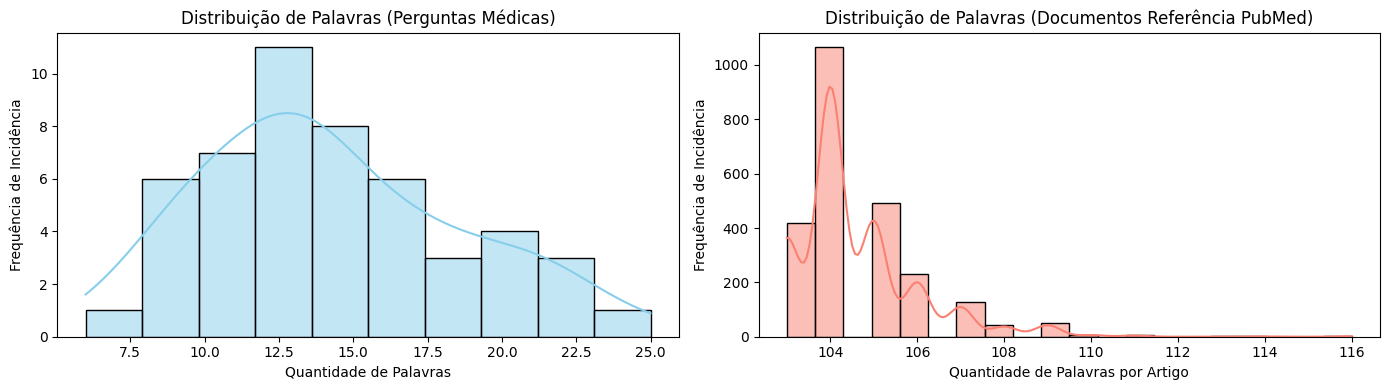

In [13]:
# Extraindo o tamanho real dos dados brutos
textos_brutos = list(documents_map.values())
tamanhos_perguntas = [len(str(q['query']).split()) for q in amostra_qa]
tamanhos_textos = [len(t.split()) for t in textos_brutos]

# Plotando as densidades para pautar nossa técnica de Chunking
fig, ax = plt.subplots(1, 2, figsize=(14, 4))

sns.histplot(tamanhos_perguntas, kde=True, ax=ax[0], color='skyblue', bins=10)
ax[0].set_title('Distribuição de Palavras (Perguntas Médicas)')
ax[0].set_xlabel('Quantidade de Palavras')
ax[0].set_ylabel('Frequência de Incidência')

sns.histplot(tamanhos_textos, kde=True, ax=ax[1], color='salmon', bins=20)
ax[1].set_title('Distribuição de Palavras (Documentos Referência PubMed)')
ax[1].set_xlabel('Quantidade de Palavras por Artigo')
ax[1].set_ylabel('Frequência de Incidência')

plt.tight_layout()

print(f"Média de palavras nas Perguntas: {np.mean(tamanhos_perguntas):.1f}")
print(
    f"Coleção Referência (Pool): {len(tamanhos_textos)} trechos contendo uma média de {np.mean(tamanhos_textos):.1f} palavras cada.")

plt.show()

## 2. Retriever


In [14]:
# Fragmentação cega pelo número bruto de letras (caracteres)
text_splitter = RecursiveCharacterTextSplitter(chunk_size=500, chunk_overlap=50)

print("Gerando Documentos (Chunks)...", flush=True)
CHUNKS = text_splitter.create_documents(textos_brutos)

print("Chamando a Inteligência da OpenAI para transcodar os Chunk em Embeddings...", flush=True)
motor_de_embeddings = OpenAIEmbeddings(model="text-embedding-3-small")
vector_db = Chroma.from_documents(CHUNKS, motor_de_embeddings)

buscador = vector_db.as_retriever(search_kwargs={"k": 3})
print("Base Vetorial pronta e engatada!", flush=True)

Base Vetorial pronta e engatada!


## 3. Gerador de resposta

In [15]:
@observe(as_type="span", name="Busca_Chroma_VectorDB")
def buscar_materiais(query: str):
    chunks = buscador.invoke(query)
    return [c.page_content for c in chunks]


@observe(as_type="generation", name="Formulador_LLM")
def formular_resposta(query: str, evidencias: list):
    modelo_inteligente = ChatOpenAI(model="gpt-4o-mini", temperature=0.0)
    prompt = ChatPromptTemplate.from_messages([
        ("system", "Responda à pergunta focando EXCLUSIVAMENTE nas evidências repassadas:\n{evidencias}"),
        ("user", "{pergunta}")
    ])
    cadeia = prompt | modelo_inteligente
    resposta = cadeia.invoke(
        {"evidencias": "\n----\n".join(evidencias), "pergunta": query},
        config={"callbacks": [handler_de_observabilidade]}
    )
    return resposta.content


@observe(name="Pipeline_AQ_MedAI")
def rodar_teste_unitario(query: str):
    evs = buscar_materiais(query)
    ans = formular_resposta(query, evs)
    return evs, ans

In [16]:
test_cases = []
print("INICIANDO EXAMES DO RAG\n", flush=True)

for idx, item in enumerate(amostra_qa):
    q = item['query']
    ground_truth = str(item['ground_truth'])
    print(f"[{idx + 1}/50] Pergunta: {q[:60]}...", flush=True)

    evs_recover, generated_ans = rodar_teste_unitario(q)
    print(f"     Resposta Elaborada: {generated_ans[:60]}...\n", flush=True)

    tc = LLMTestCase(
        input=q,
        actual_output=generated_ans,
        expected_output=ground_truth,
        retrieval_context=evs_recover
    )
    test_cases.append(tc)

langfuse.flush()

     Resposta Elaborada: As per the provided content, there is no specific informatio...



## 4. Avaliar qualidade dos resultados

In [17]:
metrica_relev = AnswerRelevancyMetric(threshold=0.5, model="gpt-4o")
metrica_faith = FaithfulnessMetric(threshold=0.5, model="gpt-4o")
metrica_recall = ContextualRecallMetric(threshold=0.5, model="gpt-4o")
metrica_precis = ContextualPrecisionMetric(threshold=0.5, model="gpt-4o")

print("⚖️ Submetendo o RAG aos Avaliadores...", flush=True)
resultados = evaluate(
    test_cases=test_cases,
    metrics=[metrica_relev, metrica_faith, metrica_recall, metrica_precis]
)

try:
    for res in test_cases:
        print(f"\n> Pergunta do Paciente: {res.input[:65]}...", flush=True)
        for metric in res.metrics_metadata:
            icone = "✅" if metric.is_successful else "❌"
            print(f"   {icone} | {metric.metric.ljust(30)} | Score: {str(metric.score).ljust(4)}", flush=True)
        print("-" * 50, flush=True)
except:
    pass


> Pergunta do Paciente: Is anorectal endosonography valuable in dyschesia?...


## 5. (Bônus) Métricas de recuperação de informação

## 6. Ferramentas: Langchain, e/ou LlamaIndex